In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 11 — Lista duplamente encadeada e Deque

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. Exercício 11 **→ você está aqui**
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 11 — Lista duplamente encadeada e Deque

## Enunciado
`DoublyLinkedList` com nós `prev`/`next` e `insert_first`, `insert_last`,
`delete_first`, `delete_last`, `is_empty`; `Deque` sobre ela com as seis
operações **O(1) nas duas pontas**; bateria de testes com sequências longas
alternando as pontas, verificando invariantes; e documentação do tratamento de
deque vazio.

## Implementação — `src/doubly_linked.py`

**Decisão de projeto 1 — o `Deque` compõe a lista, não herda dela.** Por herança
ele exporia também `insert_at`/`delete_at`, e a promessa "todas as operações são
O(1)" deixaria de valer para o tipo — um chamador poderia usar uma operação O(n)
sem perceber. Por composição, a API é exatamente as seis operações do enunciado.

**Decisão de projeto 4 — a invariante é verificada, não assumida.**
`check_invariants` confere os **dois** sentidos (`nó.next.prev is nó` e
`nó.prev.next is nó`). Um encadeamento correto só num sentido passa em qualquer
teste de `to_list()` e quebra na primeira remoção pelo outro lado.

In [4]:
from src.doubly_linked import (COST_TABLE as COST_DUPLA, DEQUE_COST_TABLE, Deque,
                               DoublyLinkedList, EmptyDequeError,
                               EmptyDoublyLinkedListError, bench_delete_last_vs_singly,
                               bench_deque_operations, run_alternating_ends_stress)

deque = Deque([2, 3])
deque.insert_left(1); deque.insert_right(4)
assert deque.to_list() == [1, 2, 3, 4]
assert deque.peek_left() == 1 and deque.peek_right() == 4
assert deque.remove_left() == 1 and deque.remove_right() == 4
deque.check_invariants()
print(f"deque: {deque}")

# composição, não herança: as operações O(n) não existem no tipo
for proibida in ("insert_at", "delete_at", "search"):
    assert not hasattr(deque, proibida)
print(f"o Deque NÃO expõe insert_at/delete_at/search: {[hasattr(deque, p) for p in ('insert_at','delete_at','search')]}")

print("\nTRATAMENTO DE DEQUE VAZIO")
vazio = Deque()
for operacao in ("remove_left", "remove_right", "peek_left", "peek_right"):
    try:
        getattr(vazio, operacao)()
    except EmptyDequeError as erro:
        print(f"  {operacao:<14} → EmptyDequeError: {erro}")
print(f"  e a exceção do Deque NÃO é a da estrutura interna: "
      f"{issubclass(EmptyDequeError, EmptyDoublyLinkedListError) = }")

deque: esquerda [2 <-> 3] direita
o Deque NÃO expõe insert_at/delete_at/search: [False, False, False]

TRATAMENTO DE DEQUE VAZIO
  remove_left    → EmptyDequeError: remove_left em deque vazio: não há o que remover
  remove_right   → EmptyDequeError: remove_right em deque vazio: não há o que remover
  peek_left      → EmptyDequeError: peek_left em deque vazio: não há o que espiar
  peek_right     → EmptyDequeError: peek_right em deque vazio: não há o que espiar
  e a exceção do Deque NÃO é a da estrutura interna: issubclass(EmptyDequeError, EmptyDoublyLinkedListError) = False


In [5]:
deque_ops = pd.DataFrame(bench_deque_operations())
pivo_deque = deque_ops.pivot(index="operacao", columns="n", values="tempo_us_por_op")
pivo_deque["pior/melhor"] = pivo_deque.max(axis=1) / pivo_deque.min(axis=1)
print("AS SEIS OPERAÇÕES DO DEQUE — tempo por operação (µs)")
print(pivo_deque.to_string())
assert (deque_ops["hops"] == 0).all()
veredito(
    f"hops = 0 em TODAS as medições, em todos os n.\n"
    f"n cresceu 16× e o custo por operação variou no máximo "
    f"{pivo_deque['pior/melhor'].max():.2f}× — ruído, não tendência. Θ(1) confirmado."
)

AS SEIS OPERAÇÕES DO DEQUE — tempo por operação (µs)
n              1000   2000   4000   8000  16000  pior/melhor
operacao                                                    
insert_left  0.2595 0.2620 0.2578 0.2761 0.2833       1.0992
insert_right 0.2511 0.2563 0.2682 0.3215 0.2977       1.2805
remove_left  0.1391 0.1384 0.1413 0.1420 0.1419       1.0264
remove_right 0.1434 0.1407 0.1411 0.1415 0.1431       1.0196

hops = 0 em TODAS as medições, em todos os n.
n cresceu 16× e o custo por operação variou no máximo 1.28× — ruído, não tendência. Θ(1) confirmado.


In [6]:
prev = pd.DataFrame(bench_delete_last_vs_singly())
mostrar(prev, ["estrutura", "n", "hops", "hops_teorico", "hops/n", "hops/n2",
               "tempo_s", "tempo_us_por_op"],
        "O QUE O PONTEIRO prev COMPRA — esvaziar a lista PELO FIM")

O QUE O PONTEIRO prev COMPRA — esvaziar a lista PELO FIM


,estrutura,n,hops,hops_teorico,hops/n,hops/n2,tempo_s,tempo_us_por_op
0,duplamente encadeada,250,0,0,0.0000,0.0000,0.0000,0.0920
1,simplesmente encadeada,250,31125,31125,124.5000,0.4980,0.0021,8.5696
2,duplamente encadeada,500,0,0,0.0000,0.0000,0.0000,0.0920
3,simplesmente encadeada,500,124750,124750,249.5000,0.4990,0.0086,17.1276
4,duplamente encadeada,1000,0,0,0.0000,0.0000,0.0001,0.1013
5,simplesmente encadeada,1000,499500,499500,499.5000,0.4995,0.0337,33.6738
6,duplamente encadeada,2000,0,0,0.0000,0.0000,0.0002,0.0927
7,simplesmente encadeada,2000,1999000,1999000,999.5000,0.4998,0.1376,68.8027
8,duplamente encadeada,4000,0,0,0.0000,0.0000,0.0004,0.0944
9,simplesmente encadeada,4000,7998000,7998000,"1,999.5000",0.4999,0.5597,139.9161


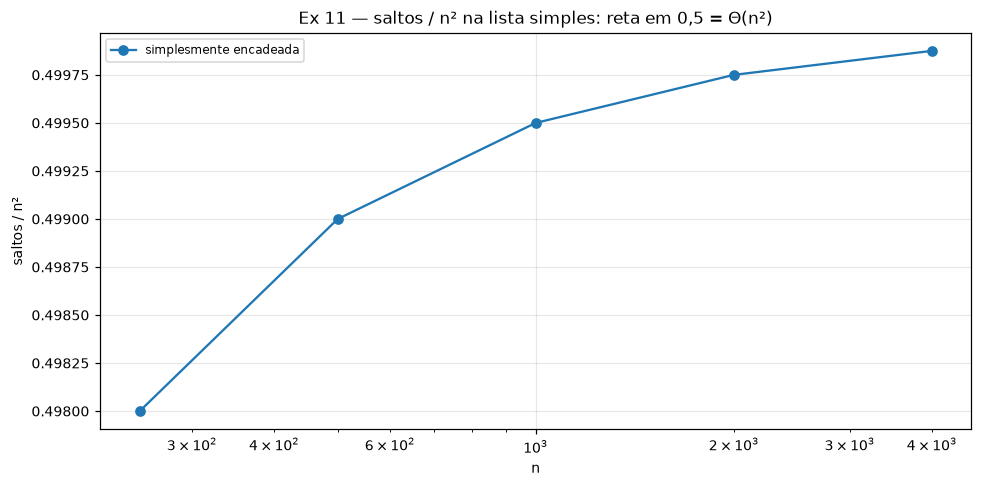

estrutura  duplamente encadeada  simplesmente encadeada  razão simples/dupla
n                                                                           
250                      0.0920                  8.5696              93.1478
500                      0.0920                 17.1276             186.1696
1000                     0.1013                 33.6738             332.4166
2000                     0.0927                 68.8027             742.2082
4000                     0.0944                139.9161           1,481.7691

DUPLA  : 0 saltos, 0,09 µs/remoção constante  ⇒ Θ(n) para esvaziar
SIMPLES: 7,998,000 saltos em n=4,000 — bate dígito a dígito com n(n−1)/2
  razão saltos/n² de 0.4980 a 0.4999 enquanto n cresce 16×  ⇒ Θ(n²)
  razão de tempo: 93× → 1,482×

O preço do prev: um ponteiro a mais por nó (memória Θ(n)) e uma religação a
mais por operação (constante). Troca-se memória linear por um fator n de tempo.


In [7]:
simples = prev[prev["estrutura"] == "simplesmente encadeada"]
grafico_razao(simples.assign(curva="simplesmente encadeada"), "n", "hops/n2", "curva",
              "Ex 11 — saltos / n² na lista simples: reta em 0,5 = Θ(n²)",
              "ex11_delete_last.png", "saltos / n²")

pivo_prev = prev.pivot(index="n", columns="estrutura", values="tempo_us_por_op")
pivo_prev["razão simples/dupla"] = (pivo_prev["simplesmente encadeada"] /
                                    pivo_prev["duplamente encadeada"])
print(pivo_prev.to_string())
veredito(
    "DUPLA  : 0 saltos, 0,09 µs/remoção constante  ⇒ Θ(n) para esvaziar\n"
    f"SIMPLES: {int(simples['hops'].max()):,} saltos em n={int(simples['n'].max()):,} — "
    "bate dígito a dígito com n(n−1)/2\n"
    f"  razão saltos/n² de {simples['hops/n2'].min():.4f} a {simples['hops/n2'].max():.4f} "
    "enquanto n cresce 16×  ⇒ Θ(n²)\n"
    f"  razão de tempo: {pivo_prev['razão simples/dupla'].min():.0f}× → "
    f"{pivo_prev['razão simples/dupla'].max():,.0f}×\n\n"
    "O preço do prev: um ponteiro a mais por nó (memória Θ(n)) e uma religação a\n"
    "mais por operação (constante). Troca-se memória linear por um fator n de tempo."
)

### Bateria longa alternando as duas pontas

In [8]:
estresse = run_alternating_ends_stress()
for chave in ("n", "verificacoes_de_invariante", "hops", "copies", "tentativas_em_vazio",
              "tamanho_final", "tamanho_maximo", "op_insert_left", "op_insert_right",
              "op_remove_left", "op_remove_right"):
    print(f"  {chave:<28} {estresse[chave]:,}")
veredito(
    f"{estresse['n']:,} operações sorteadas alternando as quatro pontas.\n"
    f"  {estresse['verificacoes_de_invariante']} verificações de invariante no meio do caminho\n"
    f"  {estresse['tentativas_em_vazio']} remoções em deque vazio, todas tratadas por EmptyDequeError\n"
    f"  {estresse['hops']} saltos de ponteiro no total\n"
    "  conteúdo conferido contra modelo de referência a cada 1.000 operações\n\n"
    "Cada verificação confere: tamanho, head.prev is None, tail.next is None,\n"
    "elos coerentes nos DOIS sentidos e travessia de volta = ida invertida."
)

  n                            20,000
  verificacoes_de_invariante   20
  hops                         0
  copies                       10,012
  tentativas_em_vazio          106
  tamanho_final                130
  tamanho_maximo               217
  op_insert_left               4,982
  op_insert_right              5,030
  op_remove_left               4,856
  op_remove_right              5,132

20,000 operações sorteadas alternando as quatro pontas.
  20 verificações de invariante no meio do caminho
  106 remoções em deque vazio, todas tratadas por EmptyDequeError
  0 saltos de ponteiro no total
  conteúdo conferido contra modelo de referência a cada 1.000 operações

Cada verificação confere: tamanho, head.prev is None, tail.next is None,
elos coerentes nos DOIS sentidos e travessia de volta = ida invertida.
